#Import Library

In [327]:
import pandas as pd # Import Pandas Library
import numpy as np # Import Numpy Library

import matplotlib.pyplot as plt # Import matplotlib Library

# Import Data

In [301]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv' # Data Source URL

In [302]:
!wget $data -O course_lead_scoring_2026.csv #

--2026-10-03 03:26:30--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278746 (272K) [text/plain]
Saving to: ‘course_lead_scoring_2026.csv’

course_lead_scoring 100%[===================>] 272.21K  --.-KB/s    in 0.03s   

2026-10-03 03:26:30 (9.23 MB/s) - ‘course_lead_scoring_2026.csv’ saved [278746/278746]



In [303]:
df = pd.read_csv('course_lead_scoring_2026.csv') # Set data to DataFrame
df.head() # display 5 top rows from data frame

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


#Data preparation

In [328]:
df.info() # Display data structure from DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               5000 non-null   object 
 1   industry                  5000 non-null   object 
 2   employment_status         5000 non-null   object 
 3   location                  5000 non-null   object 
 4   annual_income             5000 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                5000 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 351.7+ KB


In [331]:
df.describe() # Describe basic statistics

,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,50508.661000,2.089400,4.472600,0.491304,0.576600
std,24927.396949,1.188987,2.435906,0.202969,0.494147
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35082.750000,1.000000,3.000000,0.350000,0.000000
50%,52613.000000,2.000000,4.000000,0.490000,1.000000
75%,69752.750000,3.000000,6.000000,0.630000,1.000000
max,109886.000000,6.000000,13.000000,0.990000,1.000000


In [330]:
df.dtypes # check data type

,0
lead_source,object
industry,object
employment_status,object
location,object
annual_income,float64
number_of_courses_viewed,int64
interaction_count,int64
lead_score,float64
converted,int64


In [333]:
df.isnull().sum() # check total mising values in each feature

,0
lead_source,0
industry,0
employment_status,0
location,0
annual_income,0
number_of_courses_viewed,0
interaction_count,0
lead_score,0
converted,0


##For categorical features, replace them with 'NA'

In [335]:
categorical_features = list(df.dtypes[df.dtypes == 'object'].index) # Store the names of object columns in categorical_features
df[categorical_features] = df[categorical_features].fillna('NA') # Fill NA to missing value in categorical features.

## For numerical features, replace with with 0.0

In [336]:
numerical_features = list(df.dtypes[df.dtypes == 'float64'].index) # Store the names of int64 columns in numerical_features
df[numerical_features] = df[numerical_features].fillna(0.0) # Fill NA to missing value in numerical_features.

## Check Missing Values

In [337]:
df.isnull().sum() # check total missing values again

,0
lead_source,0
industry,0
employment_status,0
location,0
annual_income,0
number_of_courses_viewed,0
interaction_count,0
lead_score,0
converted,0


In [338]:
df.describe() # Describe basic statistic in again

,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,50508.661000,2.089400,4.472600,0.491304,0.576600
std,24927.396949,1.188987,2.435906,0.202969,0.494147
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35082.750000,1.000000,3.000000,0.350000,0.000000
50%,52613.000000,2.000000,4.000000,0.490000,1.000000
75%,69752.750000,3.000000,6.000000,0.630000,1.000000
max,109886.000000,6.000000,13.000000,0.990000,1.000000


#Question 1
What is the most frequent observation (mode) for the column industry?

In [339]:
df['industry'].value_counts()  # Count how many times each value appears in the industry feature

,count
industry,
technology,1173
retail,925
healthcare,840
finance,720
education,639
manufacturing,463
NA,240


# Question 2
Create the correlation matrix for the numerical features of your dataset. In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

In [340]:
features = df.drop(columns=['converted']) #  Create features by removing the target column 'converted'
numerical_features = features.select_dtypes(include='number') #  Select only numerical columns from features

In [342]:
correlation_matrix = numerical_features.corr() # Calculate correlation in each features
correlation_matrix # Display correlation matrix

,annual_income,number_of_courses_viewed,interaction_count,lead_score
annual_income,1.000000,0.161300,0.122842,0.229496
number_of_courses_viewed,0.161300,1.000000,0.721609,0.757204
interaction_count,0.122842,0.721609,1.000000,0.915746
lead_score,0.229496,0.757204,0.915746,1.000000


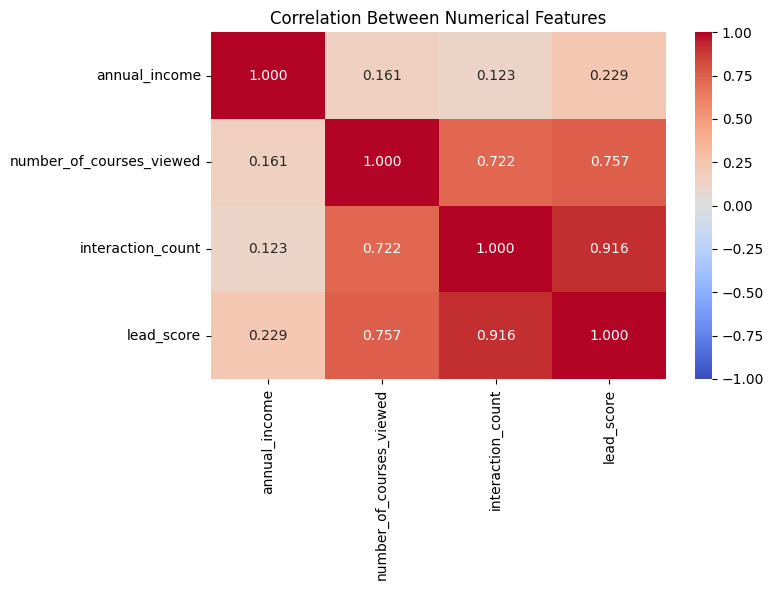

In [344]:
import seaborn as sns # Import seaborn library

plt.figure(figsize=(8, 6)) # # Create a figure that is 8 inches wide and 6 inches tall

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0
) # Create heatmap to disaply the correlation between features.

plt.title('Correlation Between Numerical Features')
plt.tight_layout()
plt.show()  # display heatmap

## interaction_count and lead_score

In [316]:
correlation_matrix.loc['interaction_count', 'lead_score'] # Correlation between interaction_count and lead_score feature

np.float64(0.9157457980418697)

## number_of_courses_viewed and lead_score

In [317]:
correlation_matrix.loc['number_of_courses_viewed', 'lead_score'] # Correlation between number_of_courses_viewed and lead_score feature

np.float64(0.7572042392104886)

## number_of_courses_viewed and interaction_count

In [318]:
correlation_matrix.loc['number_of_courses_viewed', 'interaction_count'] # Correlation between number_of_courses_viewed and interaction_count feature

np.float64(0.7216090038937035)

## annual_income and interaction_count

In [345]:
correlation_matrix.loc['annual_income', 'interaction_count'] # Correlation between annual_income and interaction_count feature

np.float64(0.12284235135955959)

# Split Data

In [347]:
from sklearn.model_selection import train_test_split # # Import the function used to split data into separate sets

# Split data to be df_full_train and  df_test
df_full_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42
)

# Split data to be ddf_train and  df_val
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=42
)


y_full_train = df_full_train.pop('converted') # Move the target column from df_full_train to y_full_train
y_train = df_train.pop('converted') # Move the target column from df_train to y_train
y_val = df_val.pop('converted') # Move the target column from df_val to y_val
y_test = df_test.pop('converted') # Move the target column from df_test to y_test

# Question 3
* Calculate the mutual information score between converted and other categorical variables in the dataset. Use the training set only.
* Round the scores to 2 decimals using round(score, 2).
Which of these variables has the biggest mutual information score?

In [350]:
from sklearn.metrics import mutual_info_score # Import the function used to calculate mutual information

columns = ['industry', 'location', 'lead_source', 'employment_status'] # Store the names of categorical features to check

mi_scores = {} # Create an empty dictionary to store the scores

for column in columns: # Check each feature in the list
    score = mutual_info_score(df_train[column], y_train) # Calculate mutual information between the feature and the target using training data
    mi_scores[column] = round(score, 2) # Store the score with the feature name and round it to 2 decimal places

mi_scores = pd.Series(mi_scores).sort_values(ascending=False) # Convert the dictionary to a Series and sort scores from highest to lowest
display(mi_scores) # Display the scores

,0
lead_source,0.03
employment_status,0.02
location,0.00
industry,0.00


#Question 4
* Now let's train a logistic regression.
* Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
* Fit the model on the training dataset.
  * To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
  * model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
* Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

What accuracy did you get?

In [351]:
from sklearn.feature_extraction import DictVectorizer  # Import the tool that converts dictionaries into numerical features
from sklearn.linear_model import LogisticRegression  # Import the logistic regression model
from sklearn.metrics import accuracy_score  # Import the function that measures the fraction of correct predictions

train_dicts = df_train.to_dict(orient='records')  # Convert training data into a list of dictionaries, one per row
val_dicts = df_val.to_dict(orient='records')  # Convert validation data into a list of dictionaries, one per row

dv = DictVectorizer(sparse=False)  # Create a vectorizer that returns a dense array
X_train = dv.fit_transform(train_dicts)  # Learn the feature columns and encode the training data
X_val = dv.transform(val_dicts)  # Encode validation data using the same feature columns

model = LogisticRegression(  # Create a logistic regression model
    solver='liblinear',  # Use liblinear to find the model weights
    C=1.0,  # Set regularization strength: smaller C means stronger regularization
    max_iter=1000,  # Allow up to 1000 optimization iterations
    random_state=42  # Set the random seed for reproducible results
)
model.fit(X_train, y_train)  # Train the model using training features and target values

y_pred = model.predict(X_val)  # Predict class 0 or 1 for each validation row
accuracy = accuracy_score(y_val, y_pred)  # Compare predictions with actual targets to calculate accuracy

print('Validation accuracy:', round(accuracy, 2))  # Print validation accuracy rounded to 2 decimal places

Validation accuracy: 0.65


#Question 5
* Let's find the least useful feature using the feature elimination technique.
* Train a model using the same features and parameters as in Q4 (without rounding).
* Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
* For each feature, calculate the difference between the original accuracy and the accuracy without the feature.

Which of following feature has the smallest difference?

In [354]:
original_accuracy = accuracy_score(y_val, model.predict(X_val))  # Calculate validation accuracy using all features without rounding

results = []  # Create an empty list to store the results

for feature in df_train.columns:  # Remove and test one feature at a time
    train_dicts_reduced = df_train.drop(columns=[feature]).to_dict(orient='records')  # Remove this feature from training data and convert rows to dictionaries
    val_dicts_reduced = df_val.drop(columns=[feature]).to_dict(orient='records')  # Remove the same feature from validation data and convert rows to dictionaries

    dv_reduced = DictVectorizer(sparse=False)  # Create a new vectorizer that returns a dense array
    X_train_reduced = dv_reduced.fit_transform(train_dicts_reduced)  # Learn the remaining feature columns and encode training data
    X_val_reduced = dv_reduced.transform(val_dicts_reduced)  # Encode validation data using the same feature columns

    model_reduced = LogisticRegression(  # Create a new model using the same settings as the original model
        solver='liblinear',  # Use liblinear to find the model weights
        C=1.0,  # Set regularization strength: smaller C means stronger regularization
        max_iter=1000,  # Allow up to 1000 optimization iterations
        random_state=42  # Set the random seed for reproducible results
    )
    model_reduced.fit(X_train_reduced, y_train)  # Train the model without the selected feature

    predictions = model_reduced.predict(X_val_reduced)  # Predict classes for the validation data
    reduced_accuracy = accuracy_score(y_val, predictions)  # Calculate accuracy without the selected feature
    difference = original_accuracy - reduced_accuracy  # Subtract the reduced accuracy from the original accuracy

    results.append({  # Add this model's results to the list
        'removed_feature': feature,  # Store the name of the removed feature
        'accuracy_without_feature': reduced_accuracy,  # Store accuracy without this feature
        'difference': difference  # Store the change in accuracy
    })

results = pd.DataFrame(results).set_index('removed_feature')  # Convert results to a table and use removed feature names as the index

print('Original accuracy:', original_accuracy)  # Print accuracy using all features
display(results)  # Display the feature elimination results

Original accuracy: 0.645


,accuracy_without_feature,difference
removed_feature,,
lead_source,0.642,0.003
industry,0.645,0.000
employment_status,0.645,0.000
location,0.645,0.000
annual_income,0.724,-0.079
number_of_courses_viewed,0.643,0.002
interaction_count,0.601,0.044
lead_score,0.644,0.001


# Question 6
* Now let's train a regularized logistic regression.
* Let's try the following values of the parameter C: [0.000001, 0.00001, 0.0001, 0.001].
* Train models using all the features as in Q4.
* Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

Which of these C leads to the best accuracy on the validation set?

In [355]:
dv = DictVectorizer(sparse=False)  # Create a vectorizer that returns a dense array

X_train = dv.fit_transform(df_train.to_dict(orient='records'))  # Convert training rows to dictionaries, learn feature columns, and encode the data
X_val = dv.transform(df_val.to_dict(orient='records'))  # Convert validation rows to dictionaries and encode them using the same feature columns

C_values = [0.000001, 0.00001, 0.0001, 0.001]  # Store the C values to test; smaller C means stronger regularization
results_q6 = []  # Create an empty list to store the results

for C in C_values:  # Train one model for each C value
    model_c = LogisticRegression(  # Create a logistic regression model
        solver='liblinear',  # Use liblinear to find the model weights
        C=C,  # Use the current C value from the loop
        max_iter=1000,  # Allow up to 1000 optimization iterations
        random_state=42  # Set the random seed for reproducible results
    )
    model_c.fit(X_train, y_train)  # Train the model using all training features and target values

    predictions = model_c.predict(X_val)  # Predict class 0 or 1 for each validation row
    score = accuracy_score(y_val, predictions)  # Calculate the fraction of correct predictions

    results_q6.append({  # Add the current model's results to the list
        'C': C,  # Store the C value
        'accuracy': round(score, 3)  # Store accuracy rounded to 3 decimal places
    })

results_q6 = pd.DataFrame(results_q6)  # Convert the results list to a table
display(results_q6)  # Display the results for all C values

best_accuracy = results_q6['accuracy'].max()  # Find the highest rounded accuracy
display(results_q6[results_q6['accuracy'] == best_accuracy])  # Display all C values that achieved the highest rounded accuracy

,C,accuracy
0,0.000001,0.598
1,0.000010,0.598
2,0.000100,0.613
3,0.001000,0.645


,C,accuracy
3,0.001,0.645
